In [1]:
import pandas as pd
import pm4py as pm
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np


In [2]:
data_final = pd.read_csv('final_data.csv', sep =',', encoding='utf-8')
data_final = data_final.drop(['case:concept:name', 'concept:name', 'time:timestamp', 'hour', 'year', 'dayofweek'], axis = 1)
data_final_case = data_final.drop(['Time', 'Time_end', 'Name', 'Stage', 'duration'], axis = 1).drop_duplicates()
data_final_case

,ID,Time_start_case,Time_end_case,case_duration,Channel,Type,Hit,Place,Model,Price,Like,month,variant,word,cycle
0,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Офис,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,9,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
10,П00002,2023-06-30 17:15:48+00:00,2023-07-03 03:20:48+00:00,2.420139,Электронная почта,Личный ущерб,Боковое столкновение,Краснодар,Infiniti QX60 Luxe,110925.0,1,6,"('Регистрация претензии', 'Проверка документов...",ABJDDEFGHI,В себя: разово
12,П00002,2023-06-30 17:15:48+00:00,2023-07-03 03:20:48+00:00,2.420139,Электронная почта,Личный ущерб,Боковое столкновение,Краснодар,Infiniti QX60 Luxe,110925.0,1,7,"('Регистрация претензии', 'Проверка документов...",ABJDDEFGHI,В себя: разово
20,П00003,2024-05-13 23:30:32+00:00,2024-05-14 20:33:32+00:00,0.877083,Офис,Личный ущерб,Переднее столкновение,Красноярск,Alfa Romeo Giulia Quadrifoglio,797810.0,4,5,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no
28,П00004,2024-09-12 19:37:14+00:00,2024-09-13 07:46:14+00:00,0.506250,Офис,Личный ущерб,Боковое столкновение,Владивосток,Hyundai Santa Cruz SEL Premium AWD,751655.0,5,9,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441503,П09995,2025-01-19 14:39:28+00:00,2025-01-21 08:39:28+00:00,1.750000,Сайт,Личный ущерб,Столкновение нескольких автомобилей,Челябинск,Honda Accord Hybrid,754035.0,4,1,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no
441511,П09996,2023-08-24 19:22:31+00:00,2023-08-27 05:30:31+00:00,2.422222,Офис,Ответственность перед третьими лицами,Заднее столкновение,Тюмень,Hyundai Ioniq,603840.0,3,8,"('Регистрация претензии', 'Проверка документов...",ABJDDDDEFGHI,В себя: многократно
441523,П09997,2023-05-22 07:36:39+00:00,2023-05-23 15:36:39+00:00,1.333333,Офис,Ответственность перед третьими лицами,Столкновение нескольких автомобилей,Барнаул,Land Rover Discovery HSE Luxury,255935.0,5,5,"('Регистрация претензии', 'Проверка документов...",ABJDEFGHI,no
441532,П09998,2023-09-26 23:49:53+00:00,2023-09-27 17:53:53+00:00,0.752778,Телефон,Личный ущерб,Опрокидывание автомобиля,Тольятти,Toyota Land Cruiser Heritage,2929865.0,5,9,"('Регистрация претензии', 'Проверка документов...",ABDKELMHI,no


In [ ]:
cycle = data_final_case.groupby('cycle')['ID'].count().reset_index()
cycle

,cycle,ID
0,no,39707
1,В себя: многократно,1721
2,В себя: разово,5367
3,Возврат,3676
4,Пинг-Понг,1638


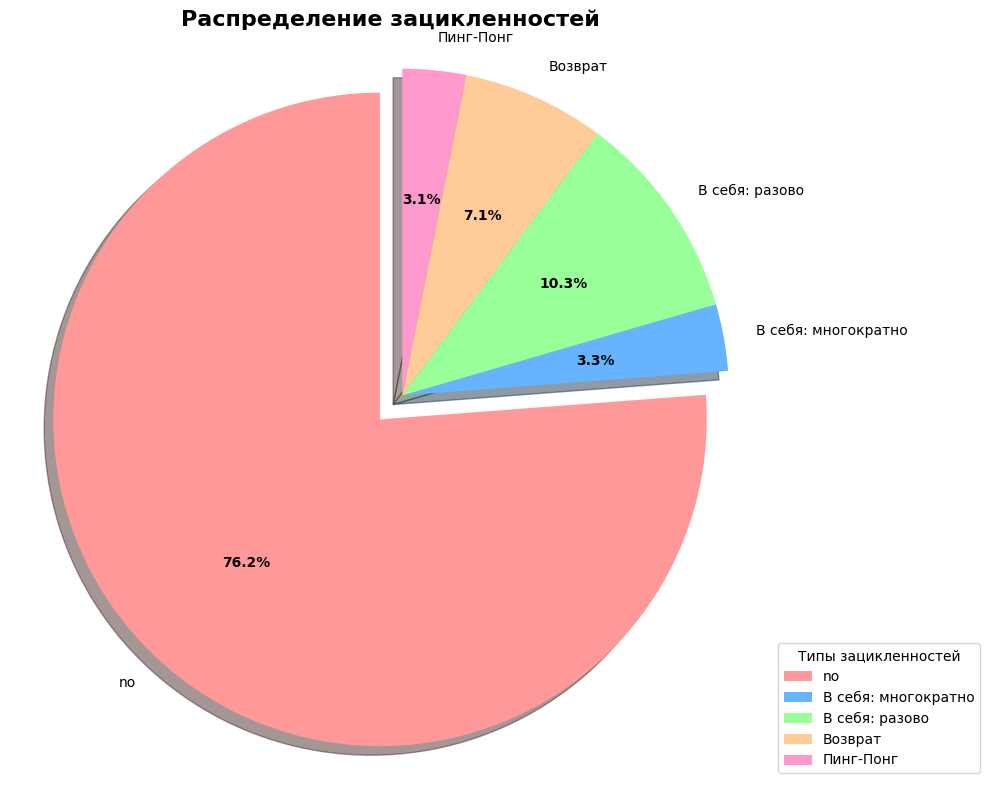

In [4]:
plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
explode = (0.1, 0, 0, 0, 0) 

wedges, texts, autotexts = plt.pie(
    cycle['ID'], 
    labels=cycle['cycle'], 
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True
)

plt.setp(autotexts, size=10, weight="bold")
plt.title('Распределение зацикленностей', fontsize=16, fontweight='bold')
plt.axis('equal') 

plt.legend(wedges, cycle['cycle'], title="Типы зацикленностей", loc="lower left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [5]:
word_cycle = data_final_case.groupby(['word', 'cycle'])['ID'].count().reset_index().sort_values(['ID'], ascending=False)
word_cycle

,word,cycle,ID
2,ABDEFGHI,no,15455
4,ABDKELMHI,no,7795
3,ABDENFGHI,no,5687
9,ABJDDEFGHI,В себя: разово,5367
10,ABJDEFGHI,no,4583
1,ABCBDEFGHI,Возврат,3676
7,ABDOPEHI,no,3126
8,ABJDDDDEFGHI,В себя: многократно,1721
0,ABCBCBDEFGHI,Пинг-Понг,1638
5,ABDKOHI,no,1557


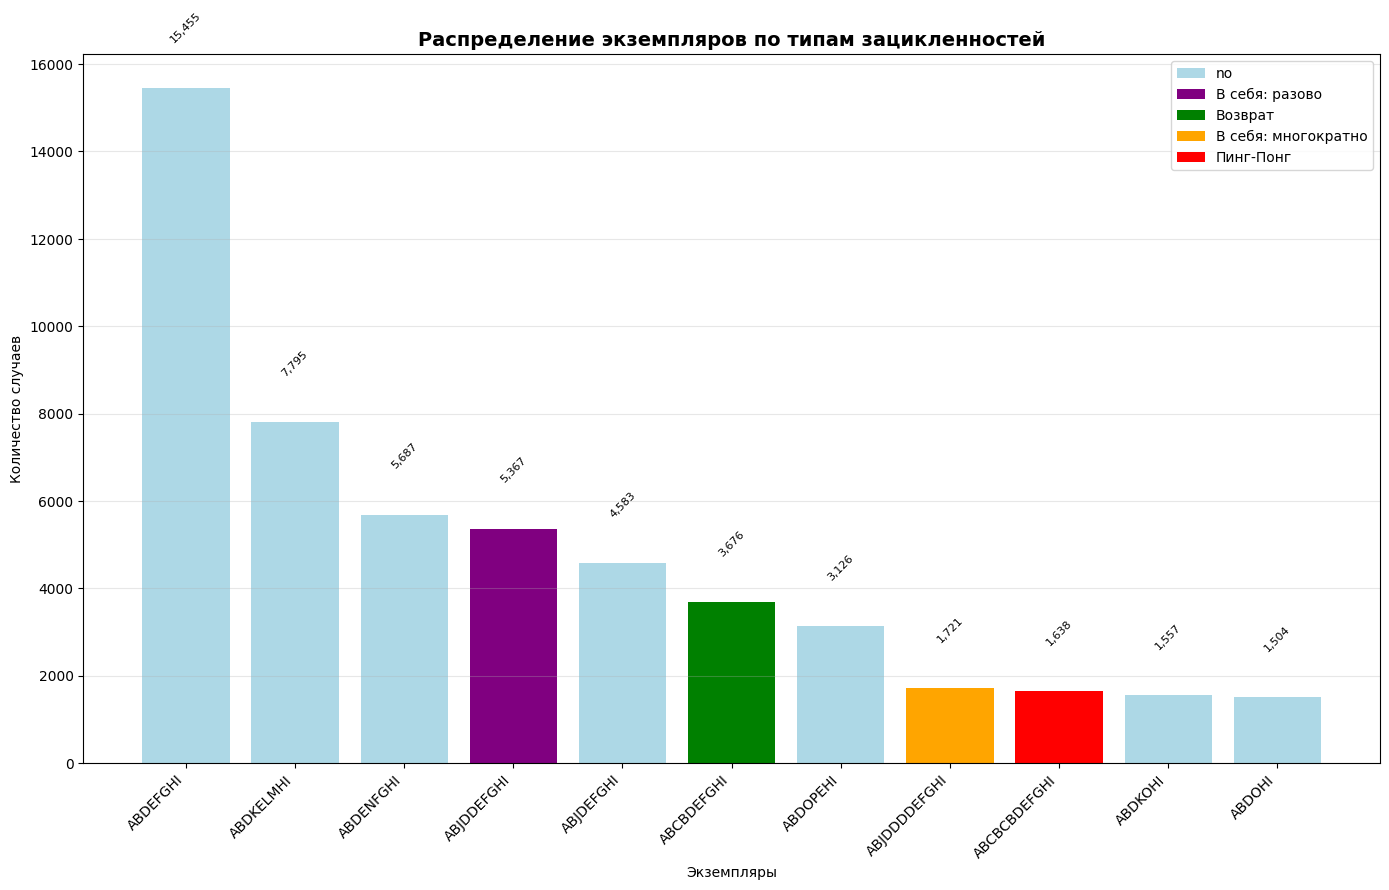

In [ ]:
plt.figure(figsize=(14, 9))

cycles = word_cycle['cycle'].unique()
colors = {'no': 'lightblue', 'Пинг-Понг': 'red', 'Возврат': 'green', 
          'В себя: многократно': 'orange', 'В себя: разово': 'purple'}

x_pos = np.arange(len(word_cycle))
bars = plt.bar(x_pos, word_cycle['ID'], color=[colors[cycle] for cycle in word_cycle['cycle']])

plt.title('Распределение экземпляров по типам зацикленностей', fontsize=14, fontweight='bold')
plt.xlabel('Экземпляры')
plt.ylabel('Количество случаев')
plt.xticks(x_pos, word_cycle['word'], rotation=45, ha='right')

for i, (value, word) in enumerate(zip(word_cycle['ID'], word_cycle['word'])):
    plt.text(i, value + 1000, f'{value:,}', ha='center', va='bottom', fontsize=8, rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cycle], label=cycle) for cycle in cycles]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
word = data_final_case.groupby('word')['ID'].count().reset_index().sort_values(['ID'], ascending=False)
word

,word,ID
2,ABDEFGHI,15455
4,ABDKELMHI,7795
3,ABDENFGHI,5687
9,ABJDDEFGHI,5367
10,ABJDEFGHI,4583
1,ABCBDEFGHI,3676
7,ABDOPEHI,3126
8,ABJDDDDEFGHI,1721
0,ABCBCBDEFGHI,1638
5,ABDKOHI,1557


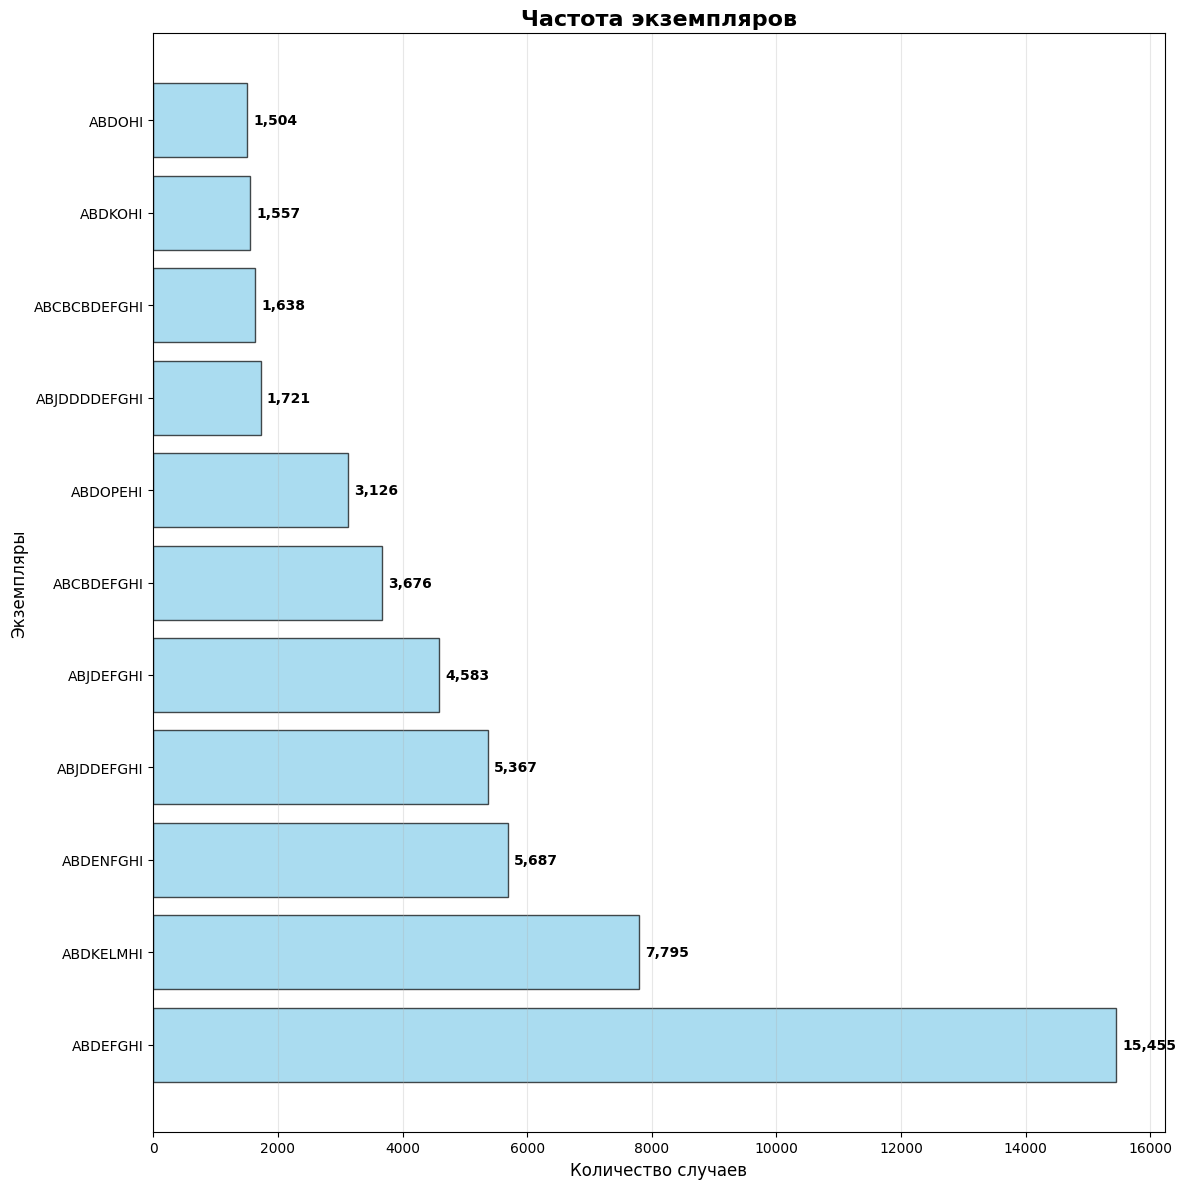

In [8]:
plt.figure(figsize=(12, 12))
bars = plt.barh(word['word'], word['ID'], color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Частота экземпляров', fontsize=16, fontweight='bold')
plt.xlabel('Количество случаев', fontsize=12)
plt.ylabel('Экземпляры', fontsize=12)

# Добавляем значения на столбцы
for i, (value, word) in enumerate(zip(word['ID'], word['word'])):
    plt.text(value + 100, i, f'{value:,}', va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
data_bad_reg = data_final[((data_final['cycle'] == 'Пинг-Понг')| (data_final['cycle'] == 'Возврат')) & (data_final['Stage'] == 'Регистрация претензии')]
bad_cadr_reg = data_bad_reg.groupby('Name')['Time'].count().reset_index().rename(columns={'Time':'Bad_reg'})
data_all_reg = data_final[data_final['Stage'] == 'Регистрация претензии']
all_cadr_reg = data_all_reg.groupby('Name')['Time'].count().reset_index().rename(columns={'Time':'All_reg'})
cadr_reg = pd.merge(bad_cadr_reg, all_cadr_reg, on = 'Name')
cadr_reg['Part: reg/all'] = cadr_reg['Bad_reg']*100/cadr_reg['All_reg']
cadr_reg = cadr_reg.sort_values('Part: reg/all', ascending=True)
cadr_reg.to_csv('reg.csv', index=False, encoding='utf-8')
cadr_reg


,Name,Bad_reg,All_reg,Part: reg/all
11,Николай Кабанов,34,428,7.943925
10,Михаил Трофимов,130,1393,9.332376
4,Геннадий Кривцов,272,2907,9.356725
6,Елизавета Нестерова,214,2210,9.683258
3,Владимир Воробьёв,142,1457,9.746054
12,Семён Афанасьев,323,3314,9.746530
1,Алёна Волкова,194,1944,9.979424
7,Инна Смирнова,335,3341,10.026938
0,Алексей Лопухин,377,3757,10.034602
2,Анна Егорова,776,7621,10.182391


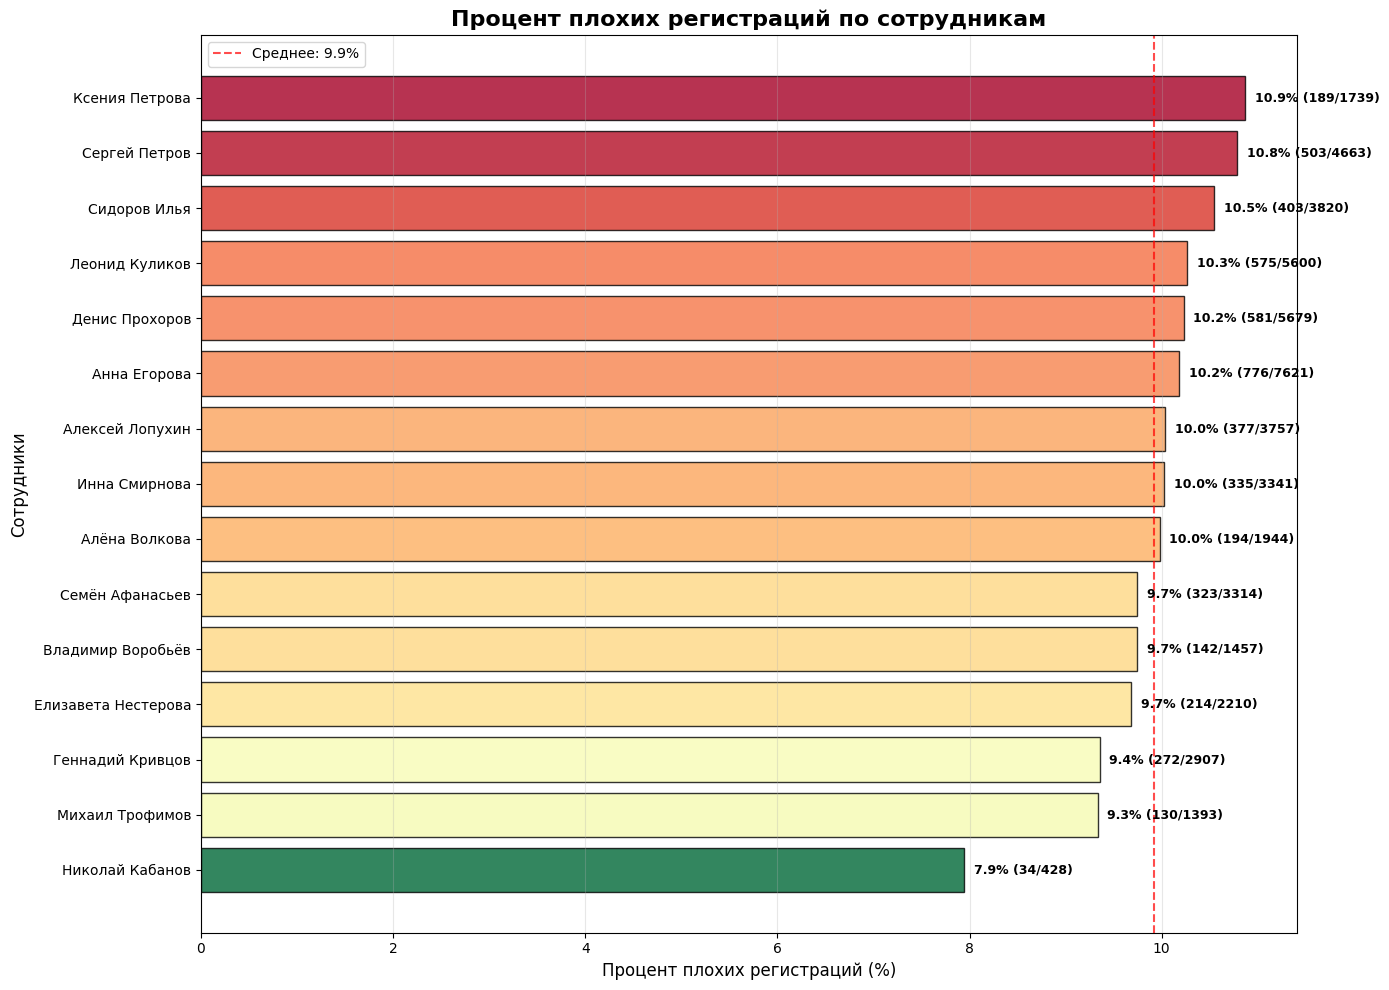

In [ ]:
plt.figure(figsize=(14, 10))
colors = plt.cm.RdYlGn_r((cadr_reg['Part: reg/all'] - cadr_reg['Part: reg/all'].min()) / 
                         (cadr_reg['Part: reg/all'].max() - cadr_reg['Part: reg/all'].min()))

bars = plt.barh(cadr_reg['Name'], cadr_reg['Part: reg/all'], color=colors, alpha=0.8, edgecolor='black')

plt.title('Процент плохих регистраций по сотрудникам', fontsize=16, fontweight='bold')
plt.xlabel('Процент плохих регистраций (%)', fontsize=12)
plt.ylabel('Сотрудники', fontsize=12)

for i, (value, bad, all_reg) in enumerate(zip(cadr_reg['Part: reg/all'], cadr_reg['Bad_reg'], cadr_reg['All_reg'])):
    plt.text(value + 0.1, i, f'{value:.1f}% ({bad}/{all_reg})', va='center', 
             fontweight='bold', fontsize=9)

mean_value = cadr_reg['Part: reg/all'].mean()
plt.axvline(mean_value, color='red', linestyle='--', alpha=0.7, 
            label=f'Среднее: {mean_value:.1f}%')

plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
data_ppp = data_final[(data_final['cycle'] == 'Пинг-Понг') & (data_final['Stage'] == 'Поиск потерянной документации')]
data_ppp_min = data_ppp.groupby('ID')['Time'].min().reset_index()
data_buf = data_final[['ID','Time','Name']]
data_p = pd.merge(data_ppp_min, data_buf, on = ['ID', "Time"])
bad_search = data_p.groupby('Name')['ID'].count().reset_index().rename(columns={'ID':'Bad_search'})
data_search = data_final[data_final['Stage'] == 'Поиск потерянной документации']
all_search = data_search.groupby('Name')['Stage'].count().reset_index().rename(columns={'Stage':'All_search'})
cadr_search = pd.merge(bad_search, all_search, on = 'Name')
cadr_search['Part: bad/all'] = cadr_search['Bad_search']*100/cadr_search['All_search']
cadr_search = cadr_search.sort_values('Part: bad/all', ascending=True)
cadr_search.to_csv('search.csv', index=False, encoding='utf-8')
cadr_search

,Name,Bad_search,All_search,Part: bad/all
11,Николай Кабанов,8,48,16.666667
8,Ксения Петрова,45,222,20.270270
4,Геннадий Кривцов,78,377,20.689655
1,Алёна Волкова,56,268,20.895522
6,Елизавета Нестерова,60,275,21.818182
3,Владимир Воробьёв,45,205,21.951220
13,Сергей Петров,135,604,22.350993
7,Инна Смирнова,97,431,22.505800
0,Алексей Лопухин,122,526,23.193916
9,Леонид Куликов,184,765,24.052288


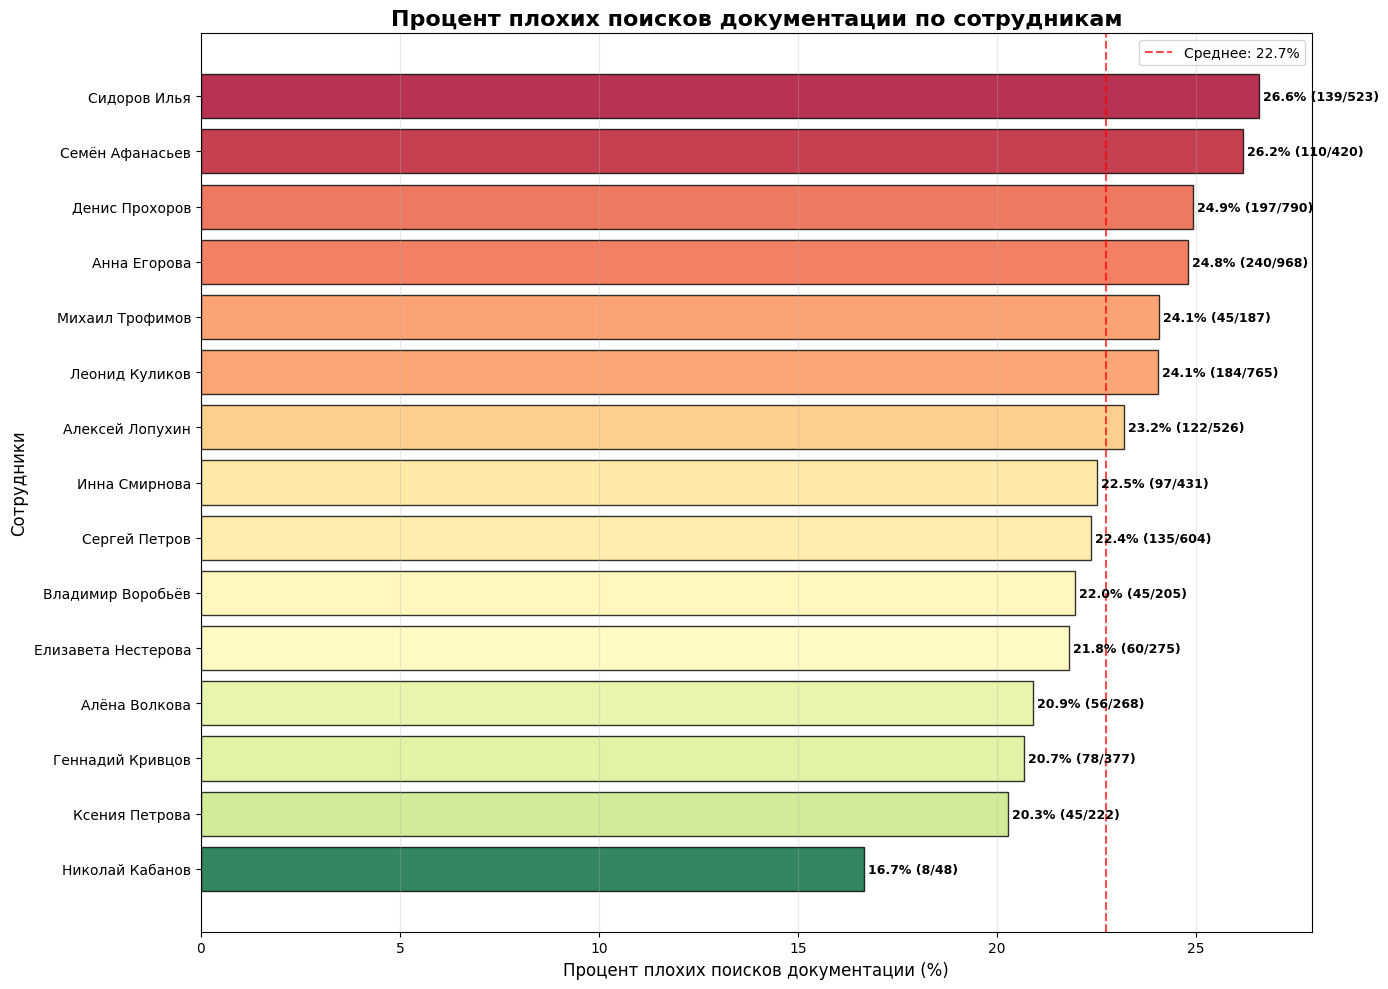

In [ ]:
plt.figure(figsize=(14, 10))
colors = plt.cm.RdYlGn_r((cadr_search['Part: bad/all'] - cadr_search['Part: bad/all'].min()) / 
                         (cadr_search['Part: bad/all'].max() - cadr_search['Part: bad/all'].min()))

bars = plt.barh(cadr_search['Name'], cadr_search['Part: bad/all'], color=colors, alpha=0.8, edgecolor='black')

plt.title('Процент плохих поисков документации по сотрудникам', fontsize=16, fontweight='bold')
plt.xlabel('Процент плохих поисков документации (%)', fontsize=12)
plt.ylabel('Сотрудники', fontsize=12)

for i, (value, bad, all_reg) in enumerate(zip(cadr_search['Part: bad/all'], cadr_search['Bad_search'], cadr_search['All_search'])):
    plt.text(value + 0.1, i, f'{value:.1f}% ({bad}/{all_reg})', va='center', 
             fontweight='bold', fontsize=9)

mean_value = cadr_search['Part: bad/all'].mean()
plt.axvline(mean_value, color='red', linestyle='--', alpha=0.7, 
            label=f'Среднее: {mean_value:.1f}%')

plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
cadr_work = data_final.groupby('Name')['Stage'].count().reset_index().sort_values('Stage', ascending=True)
cadr_work

,Name,Stage
11,Николай Кабанов,3641
10,Михаил Трофимов,12273
3,Владимир Воробьёв,13118
8,Ксения Петрова,14957
1,Алёна Волкова,17977
6,Елизавета Нестерова,19367
4,Геннадий Кривцов,25333
12,Семён Афанасьев,29545
7,Инна Смирнова,29978
0,Алексей Лопухин,33401


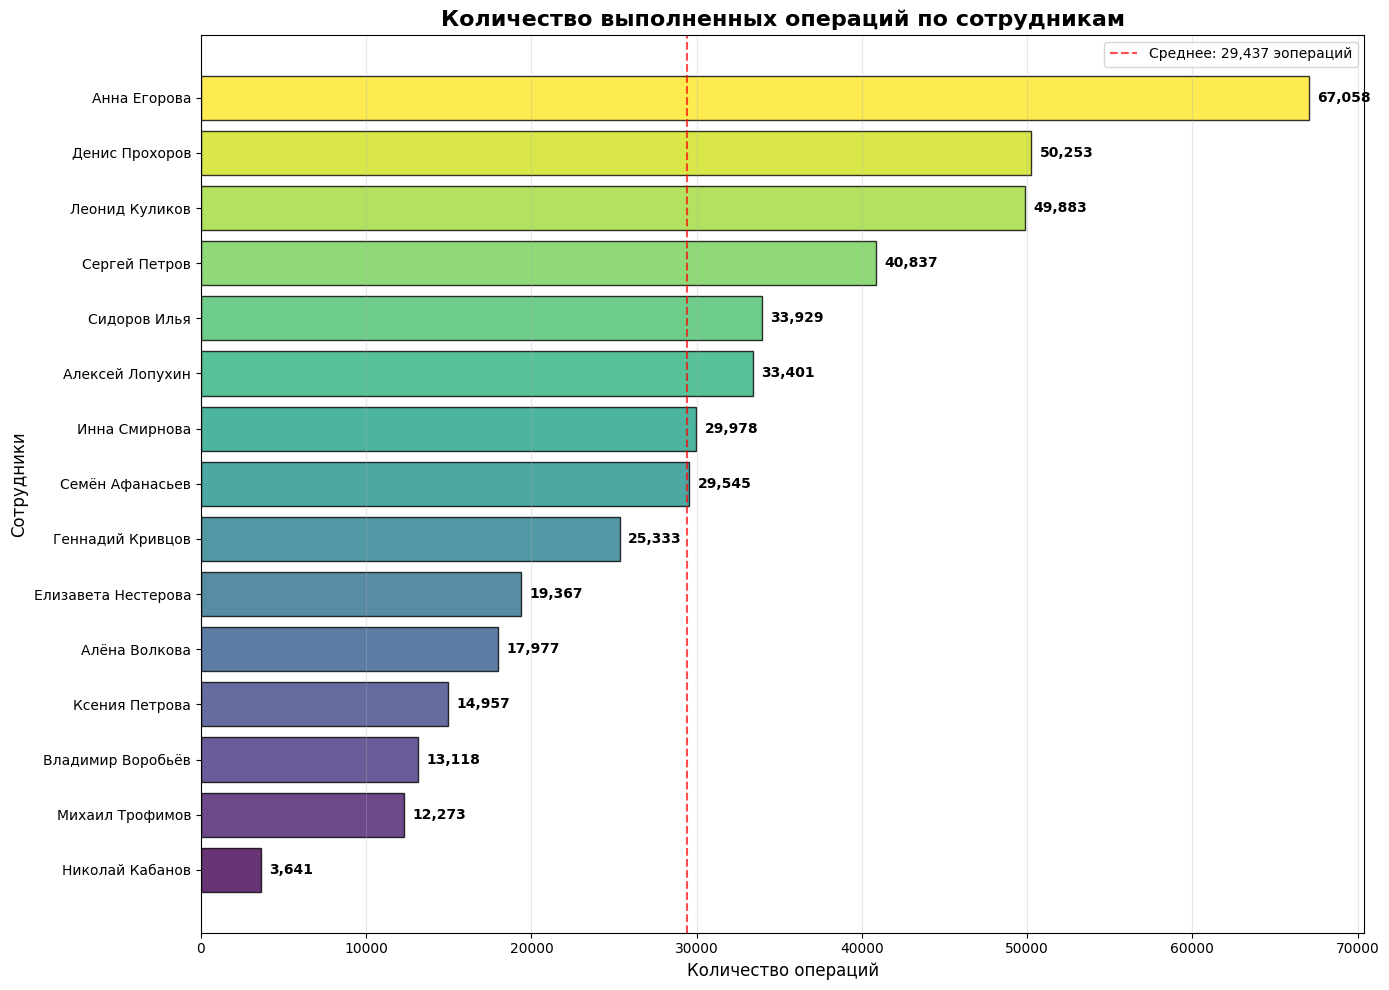

In [ ]:
plt.figure(figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(cadr_work)))
bars = plt.barh(cadr_work['Name'], cadr_work['Stage'], color=colors, alpha=0.8, edgecolor='black')

plt.title('Количество выполненных операций по сотрудникам', fontsize=16, fontweight='bold')
plt.xlabel('Количество операций', fontsize=12)
plt.ylabel('Сотрудники', fontsize=12)

for i, (value, name) in enumerate(zip(cadr_work['Stage'], cadr_work['Name'])):
    plt.text(value + 500, i, f'{value:,}', va='center', fontweight='bold', fontsize=10)

mean_value = cadr_work['Stage'].mean()
plt.axvline(mean_value, color='red', linestyle='--', alpha=0.7, 
            label=f'Среднее: {mean_value:,.0f} эопераций')

plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()

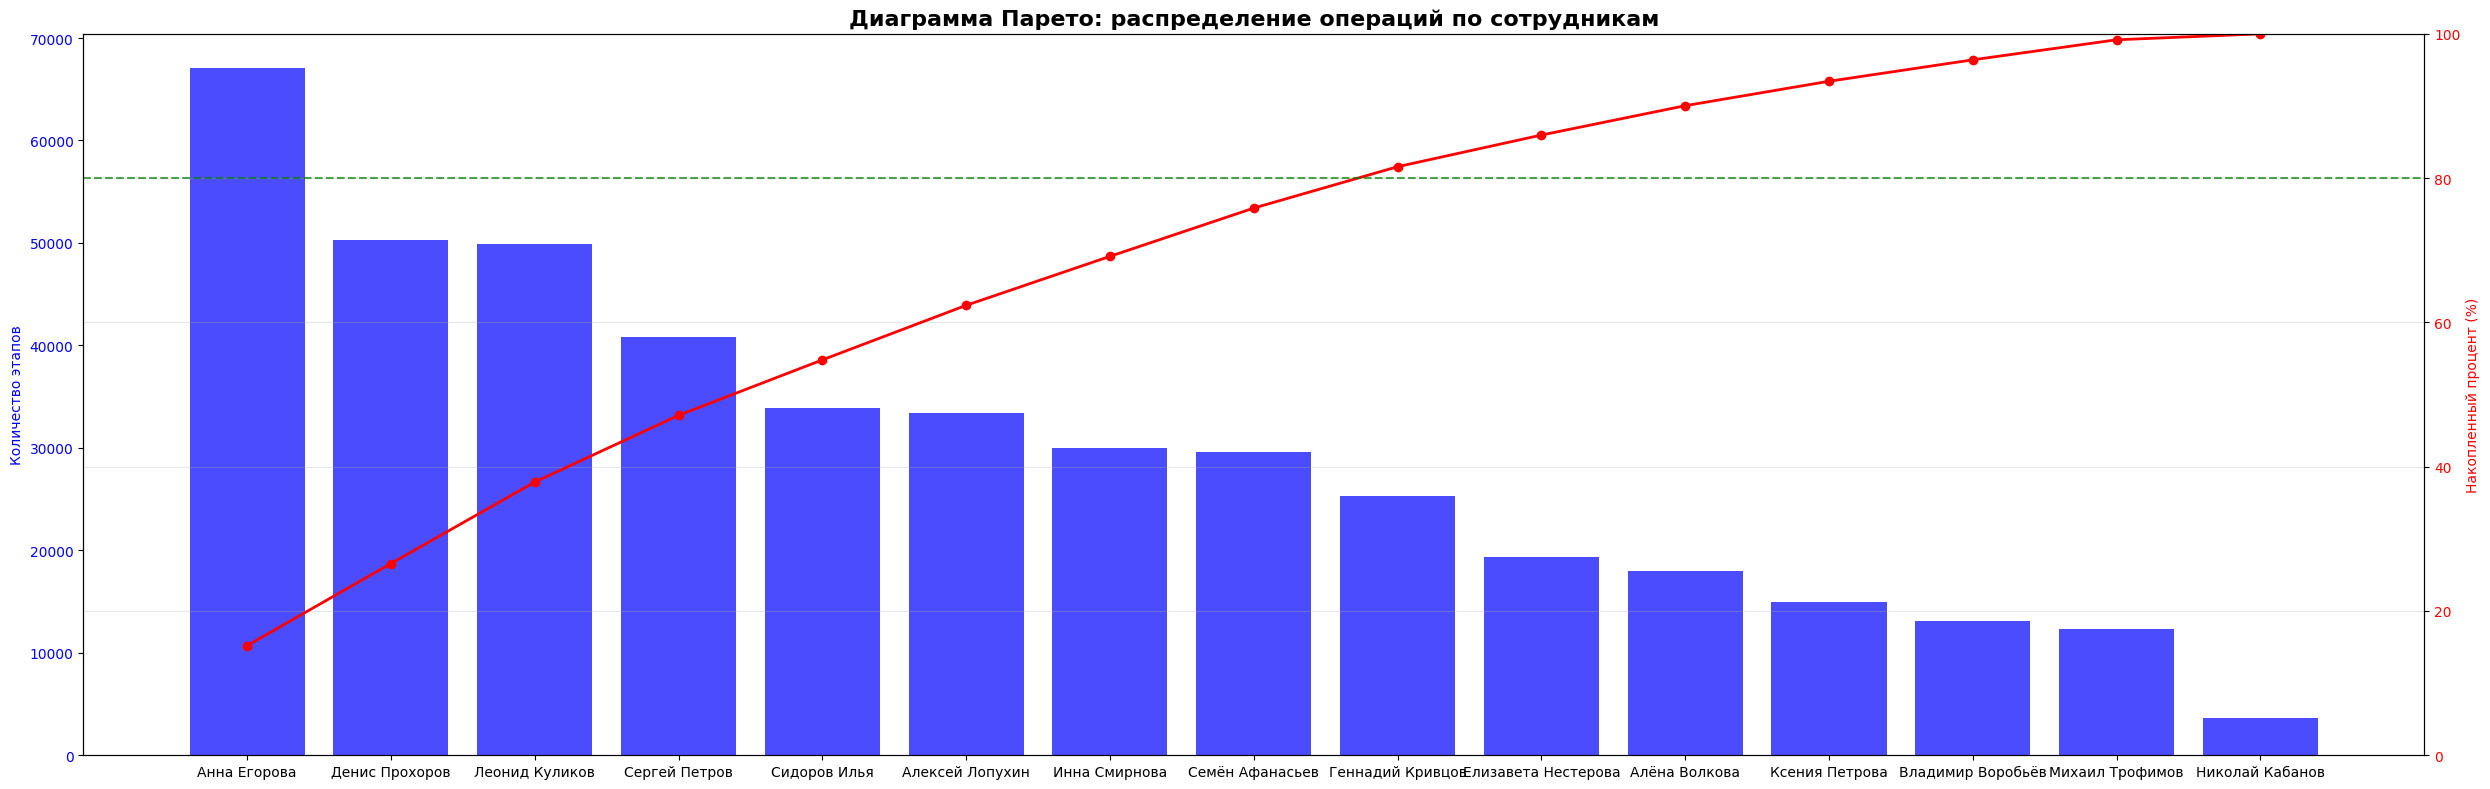

In [ ]:
plt.figure(figsize=(25, 8))

df_pareto = cadr_work.sort_values('Stage', ascending=False)
df_pareto['Cumulative Percentage'] = (df_pareto['Stage'].cumsum() / df_pareto['Stage'].sum()) * 100

ax1 = plt.gca()
bars = ax1.bar(range(len(df_pareto)), df_pareto['Stage'], color='blue', alpha=0.7)
ax1.set_ylabel('Количество этапов', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(range(len(df_pareto)), df_pareto['Cumulative Percentage'], 
         color='red', marker='o', linewidth=2)
ax2.set_ylabel('Накопленный процент (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

plt.title('Диаграмма Парето: распределение операций по сотрудникам', fontsize=16, fontweight='bold')
plt.xticks(range(len(df_pareto)), df_pareto['Name'], rotation=90, ha='right')

ax2.axhline(80, color='green', linestyle='--', alpha=0.7, label='80%')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

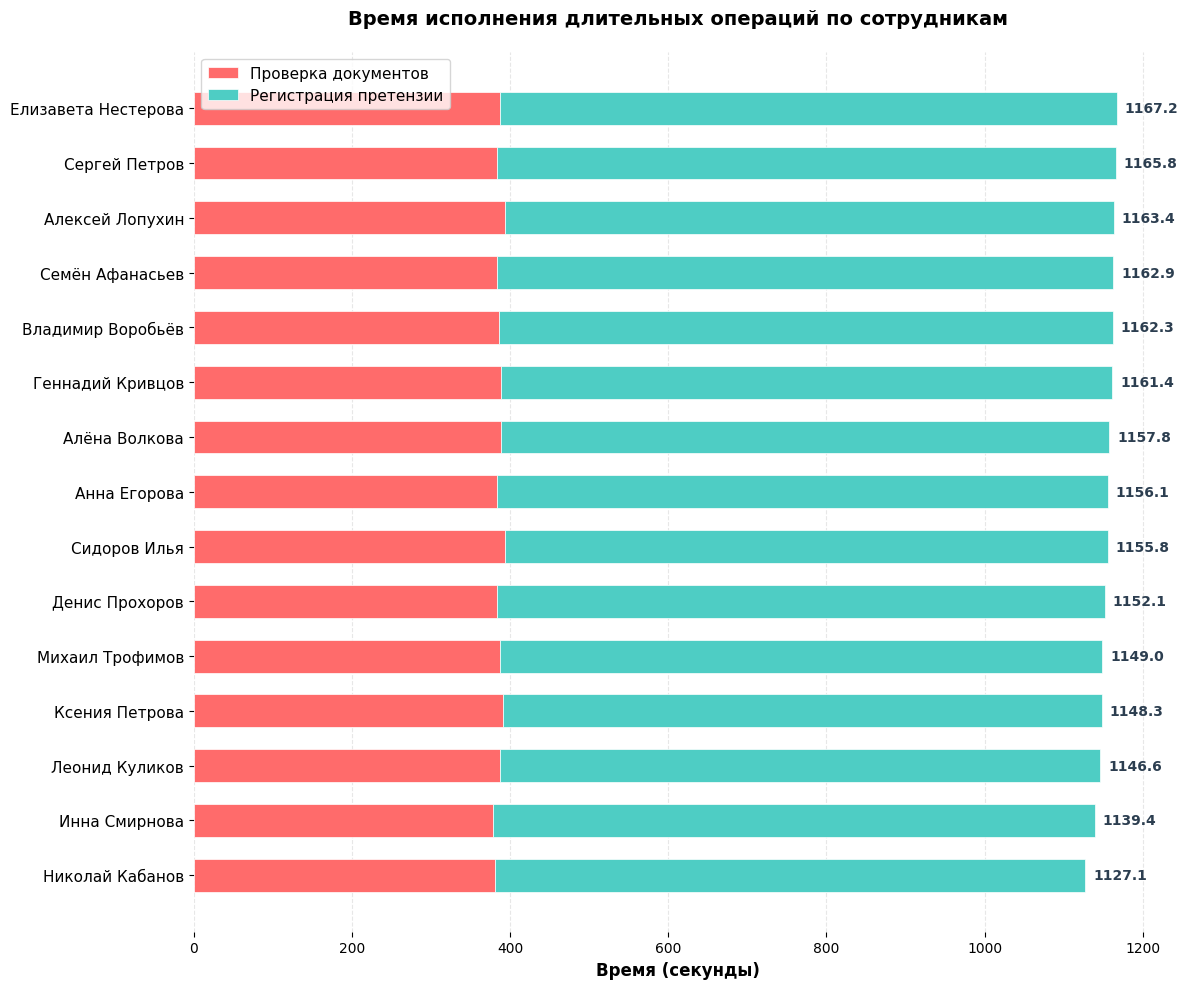

In [16]:
names = [
    'Николай Кабанов', 'Инна Смирнова', 'Леонид Куликов', 'Ксения Петрова',
    'Михаил Трофимов', 'Денис Прохоров', 'Сидоров Илья', 'Анна Егорова',
    'Алёна Волкова', 'Геннадий Кривцов', 'Владимир Воробьёв', 'Семён Афанасьев',
    'Алексей Лопухин', 'Сергей Петров', 'Елизавета Нестерова'
]

duration_check = [
    380.41, 377.80, 386.85, 390.34, 387.27, 384.01, 393.26, 383.14,
    387.91, 388.86, 385.71, 383.31, 393.91, 383.80, 387.36
]

duration_reg = [
    746.73, 761.56, 759.71, 757.92, 761.75, 768.11, 762.57, 772.92,
    769.86, 772.54, 776.64, 779.56, 769.48, 781.97, 779.85
]

sorted_data = sorted(zip(names, duration_check, duration_reg), 
                    key=lambda x: x[1] + x[2], reverse=False)
names_sorted, check_sorted, reg_sorted = zip(*sorted_data)

fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(names_sorted))

bars1 = ax.barh(y_pos, check_sorted, height=0.6, label='Проверка документов', 
               color='#FF6B6B', edgecolor='white', linewidth=0.5)
bars2 = ax.barh(y_pos, reg_sorted, height=0.6, label='Регистрация претензии', 
               left=check_sorted, color='#4ECDC4', edgecolor='white', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(names_sorted, fontsize=11)
ax.set_xlabel('Время (секунды)', fontsize=12, fontweight='bold')
ax.set_title('Время исполнения длительных операций по сотрудникам', 
             fontsize=14, fontweight='bold', pad=20)

for i, (check, reg) in enumerate(zip(check_sorted, reg_sorted)):
    total = check + reg
    ax.text(total + 10, i, f'{total:.1f}', va='center', fontsize=10, 
           fontweight='bold', color='#2C3E50')

ax.legend(loc= 'upper left', fontsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
percent_stage = data_final.groupby(['ID', 'Stage'])['duration'].sum().reset_index()
pivot_table_stage = percent_stage.pivot_table(index = 'Stage', columns = 'ID', values = 'duration', sort = False).sort_index(axis=1).fillna(0)
pivot_table_stage

ID,П00001,П00002,П00003,П00004,П00005,П00006,П00007,П00008,П00009,П00010,...,П09990,П09991,П09992,П09993,П09994,П09995,П09996,П09997,П09998,П09999
Stage,,,,,,,,,,,,,,,,,,,,,
Закрытие страхового случая,120.0,60.0,120.0,60.0,120.0,120.0,60.0,120.0,60.0,60.0,...,60.0,60.0,60.0,60.0,60.0,60.0,60.0,120.0,120.0,120.0
Обзор произошедшего случая,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Подготовка итоговой документации,60.0,120.0,120.0,120.0,120.0,60.0,0.0,120.0,0.0,60.0,...,120.0,60.0,120.0,60.0,120.0,60.0,120.0,60.0,0.0,60.0
Поиск потерянной документации,120.0,0.0,0.0,0.0,0.0,120.0,0.0,0.0,0.0,0.0,...,0.0,60.0,120.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Проверка документов,1440.0,540.0,480.0,4.0,660.0,7.0,480.0,3.0,2.0,480.0,...,720.0,1080.0,603.0,720.0,420.0,480.0,720.0,420.0,360.0,360.0
Регистрация претензии,300.0,5.0,360.0,360.0,240.0,240.0,240.0,2.0,240.0,240.0,...,300.0,360.0,300.0,360.0,300.0,360.0,240.0,300.0,300.0,300.0
Ремонт автомобиля,120.0,120.0,120.0,120.0,60.0,120.0,0.0,60.0,0.0,60.0,...,60.0,120.0,120.0,60.0,120.0,60.0,120.0,60.0,0.0,60.0
Урегулирование претензии,1200.0,2460.0,3.0,5.0,1200.0,780.0,1200.0,720.0,840.0,720.0,...,3185.0,840.0,1440.0,2280.0,1380.0,1380.0,2048.0,780.0,4.0,3.0
Утверждение претензии,120.0,60.0,60.0,60.0,60.0,120.0,120.0,120.0,60.0,60.0,...,60.0,60.0,60.0,60.0,60.0,120.0,60.0,60.0,60.0,120.0


In [18]:
def percent_group(df, index, columns, values):
    group_data = df.groupby([index, columns])['ID'].count()
    data_percent = (group_data / group_data.groupby(index).transform('sum') * 100).round(2).reset_index()
    pivot_data = data_percent.pivot_table(index = index, columns = columns, values = values, sort = False).sort_index(axis=1)
    return pivot_data

In [19]:
pivot_table_percent = pivot_table_stage.div(pivot_table_stage.sum(axis=0)) * 100
pivot_table_percent = pivot_table_percent.fillna(0).round(2)
pivot_table_percent

ID,П00001,П00002,П00003,П00004,П00005,П00006,П00007,П00008,П00009,П00010,...,П09990,П09991,П09992,П09993,П09994,П09995,П09996,П09997,П09998,П09999
Stage,,,,,,,,,,,,,,,,,,,,,
Закрытие страхового случая,3.45,1.72,9.50,8.23,4.76,7.66,2.5,10.48,4.16,3.57,...,1.31,2.27,2.13,1.64,2.33,2.38,1.72,6.25,11.07,11.08
Обзор произошедшего случая,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Подготовка итоговой документации,1.72,3.44,9.50,16.46,4.76,3.83,0.0,10.48,0.00,3.57,...,2.63,2.27,4.25,1.64,4.65,2.38,3.44,3.12,0.00,5.54
Поиск потерянной документации,3.45,0.00,0.00,0.00,0.00,7.66,0.0,0.00,0.00,0.00,...,0.00,2.27,4.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Проверка документов,41.38,15.49,38.00,0.55,26.19,0.45,20.0,0.26,0.14,28.57,...,15.77,40.91,21.36,19.67,16.28,19.05,20.64,21.88,33.21,33.24
Регистрация претензии,8.62,0.14,28.50,49.38,9.52,15.32,10.0,0.17,16.64,14.29,...,6.57,13.64,10.63,9.84,11.63,14.29,6.88,15.62,27.68,27.70
Ремонт автомобиля,3.45,3.44,9.50,16.46,2.38,7.66,0.0,5.24,0.00,3.57,...,1.31,4.55,4.25,1.64,4.65,2.38,3.44,3.12,0.00,5.54
Урегулирование претензии,34.48,70.59,0.24,0.69,47.62,49.78,50.0,62.88,58.25,42.86,...,69.77,31.82,51.01,62.30,53.49,54.76,58.72,40.62,0.37,0.28
Утверждение претензии,3.45,1.72,4.75,8.23,2.38,7.66,5.0,10.48,4.16,3.57,...,1.31,2.27,2.13,1.64,2.33,4.76,1.72,3.12,5.54,11.08


In [20]:
mean_percentage = pivot_table_percent.mean(axis=1)
mean_percentage_sorted = mean_percentage.sort_values(ascending=False).round(2)
mean_percentage_sorted

Stage
Урегулирование претензии                                     40.22
Проверка документов                                          23.05
Регистрация претензии                                        11.26
Закрытие страхового случая                                    5.77
Утверждение претензии                                         5.31
Подготовка итоговой документации                              4.00
Ремонт автомобиля                                             4.00
Урегулирование объёма убытков                                 1.13
Проверка на мошенничество                                     0.95
Получение страховых резервов                                  0.91
Отправка платежа                                              0.91
Отклонение претензии                                          0.86
Получение права на предъявление претензий от страхователя     0.67
Поиск потерянной документации                                 0.57
Предъявление апелляции по претензии                     

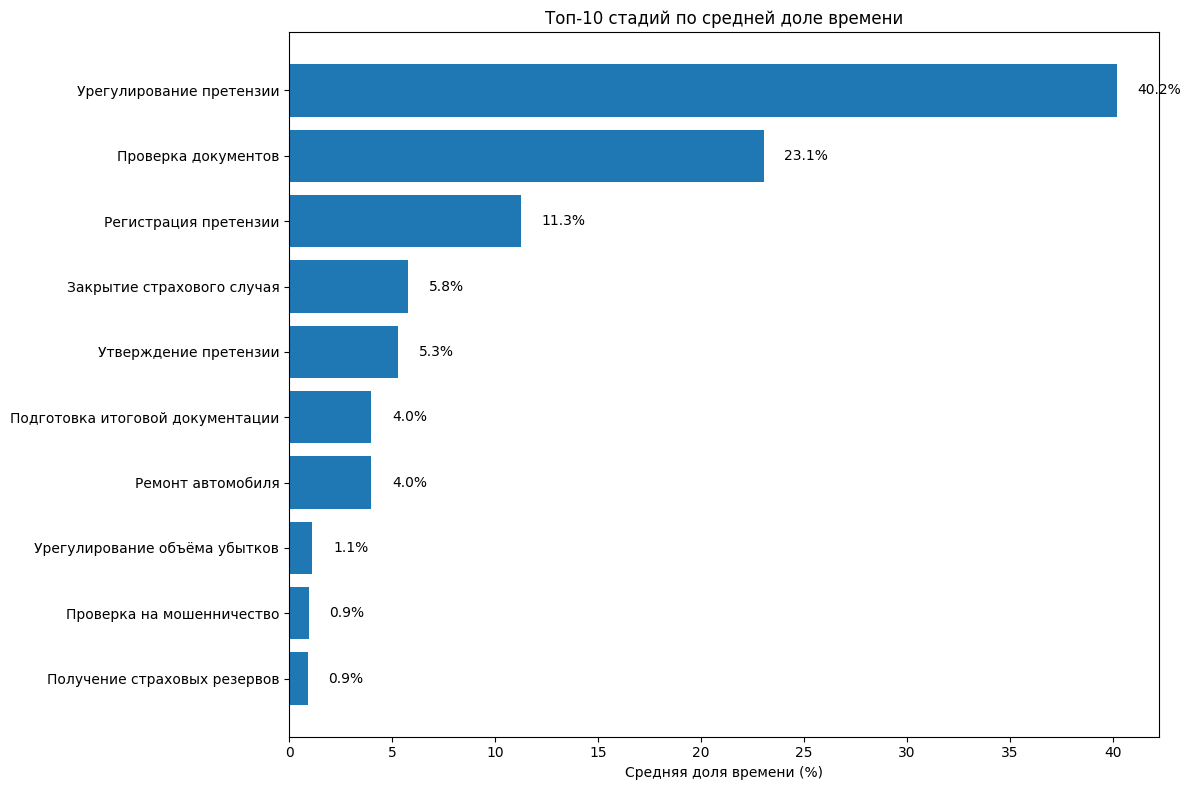

In [21]:
top_10_stages = mean_percentage_sorted.head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_10_stages.index, top_10_stages.values)
plt.xlabel('Средняя доля времени (%)')
plt.title('Топ-10 стадий по средней доле времени')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

In [22]:
month_case = data_final_case.groupby('month')['ID'].count()
month_case

month
1     4278
2     4061
3     4415
4     4279
5     4390
6     4389
7     4351
8     4428
9     4270
10    4479
11    4354
12    4415
Name: ID, dtype: int64

In [23]:
data_ppp = data_final[((data_final['cycle'] == 'Пинг-Понг') | (data_final['cycle'] == 'Возврат')) & (data_final['Stage'] == 'Регистрация претензии')]
data_ppp_min = data_ppp.groupby('ID')['Time'].min().reset_index()
data_p = pd.merge(data_ppp_min, data_final, on = ['ID', "Time"])
data_p

,ID,Time,Time_start_case,Time_end_case,case_duration,Stage,Channel,Name,Type,Hit,Place,Model,Price,Like,Time_end,duration,month,variant,word,cycle
0,П00001,2023-09-12 04:32:23+00:00,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Регистрация претензии,Офис,Денис Прохоров,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 09:32:23+00:00,300.0,9,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
1,П00006,2024-03-09 16:11:23+00:00,2024-03-09 16:11:23+00:00,2024-03-10 18:18:23+00:00,1.088194,Регистрация претензии,Сайт,Алексей Лопухин,Личный ущерб,Боковое столкновение,Тольятти,Acura MDX Elite Package,627555.0,1,2024-03-09 20:11:23+00:00,240.0,3,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
2,П00014,2023-03-23 15:23:24+00:00,2023-03-23 15:23:24+00:00,2023-03-25 05:29:24+00:00,1.587500,Регистрация претензии,Сайт,Сидоров Илья,Личный ущерб,Заднее столкновение,Благовещенск,GMC Acadia,318665.0,2,2023-03-23 15:27:24+00:00,4.0,3,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
3,П00018,2023-09-03 04:20:00+00:00,2023-09-03 04:20:00+00:00,2023-09-04 13:26:00+00:00,1.379167,Регистрация претензии,Сайт,Сидоров Илья,Личный ущерб,Переднее столкновение,Барнаул,Volkswagen ID.4 Pro,448970.0,1,2023-09-03 07:20:00+00:00,180.0,9,"('Регистрация претензии', 'Проверка документов...",ABCBCBDEFGHI,Пинг-Понг
4,П00023,2023-10-14 23:40:30+00:00,2023-10-14 23:40:30+00:00,2023-10-16 23:40:30+00:00,2.000000,Регистрация претензии,Сайт,Елизавета Нестерова,Личный ущерб,Столкновение нескольких автомобилей,Краснодар,Mazda MX-5 Miata RF,147900.0,1,2023-10-15 02:40:30+00:00,180.0,10,"('Регистрация претензии', 'Проверка документов...",ABCBCBDEFGHI,Пинг-Понг
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5043,П09936,2023-03-19 20:15:22+00:00,2023-03-19 20:15:22+00:00,2023-03-21 23:20:22+00:00,2.128472,Регистрация претензии,Электронная почта,Анна Егорова,Ответственность перед третьими лицами,Переднее столкновение,Краснодар,Nissan Armada Platinum,166940.0,2,2023-03-20 02:15:22+00:00,360.0,3,"('Регистрация претензии', 'Проверка документов...",ABCBCBDEFGHI,Пинг-Понг
5044,П09965,2023-04-27 05:12:19+00:00,2023-04-27 05:12:19+00:00,2023-04-29 07:17:19+00:00,2.086806,Регистрация претензии,Сайт,Анна Егорова,Личный ущерб,Столкновение при боковом движении,Барнаул,Chery Exeed JET,605540.0,1,2023-04-27 09:12:19+00:00,240.0,4,"('Регистрация претензии', 'Проверка документов...",ABCBCBDEFGHI,Пинг-Понг
5045,П09966,2024-09-21 03:54:50+00:00,2024-09-21 03:54:50+00:00,2024-09-22 14:01:50+00:00,1.421528,Регистрация претензии,Офис,Анна Егорова,Ответственность перед третьими лицами,Переднее столкновение,Краснодар,Buick Encore GX Select,87890.0,3,2024-09-21 06:54:50+00:00,180.0,9,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
5046,П09991,2024-05-30 19:57:26+00:00,2024-05-30 19:57:26+00:00,2024-06-01 15:57:26+00:00,1.833333,Регистрация претензии,Электронная почта,Алексей Лопухин,Ответственность перед третьими лицами,Столкновение нескольких автомобилей,Екатеринбург,Chevrolet Silverado High Country 2024 AWD,545700.0,2,2024-05-31 01:57:26+00:00,360.0,5,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат


In [24]:
search_channel = data_p.groupby('Channel')['ID'].count().reset_index()
a = search_channel['ID'].sum()
search_channel['ID'] = search_channel['ID']*100/a
search_channel

,Channel,ID
0,Офис,29.377971
1,Сайт,63.926307
2,Телефон,1.782884
3,Электронная почта,4.912837


In [25]:
all_channel = data_final_case.groupby('Channel')['ID'].count().reset_index()
a = all_channel['ID'].sum()
all_channel['ID'] = all_channel['ID']*100/a
all_channel

,Channel,ID
0,Офис,29.960276
1,Сайт,62.979524
2,Телефон,2.045712
3,Электронная почта,5.014489


In [26]:
search_price = data_p['Price'].mean()
search_price

np.float64(460534.98415213946)

In [27]:
all_price = data_final_case['Price'].mean()
all_price

np.float64(838426.0793720854)

In [28]:
price = data_final_case.groupby('cycle')['Price'].mean().reset_index()
price

,cycle,Price
0,no,955019.365603
1,В себя: многократно,466709.662987
2,В себя: разово,470006.193404
3,Возврат,460667.535365
4,Пинг-Понг,457537.356532


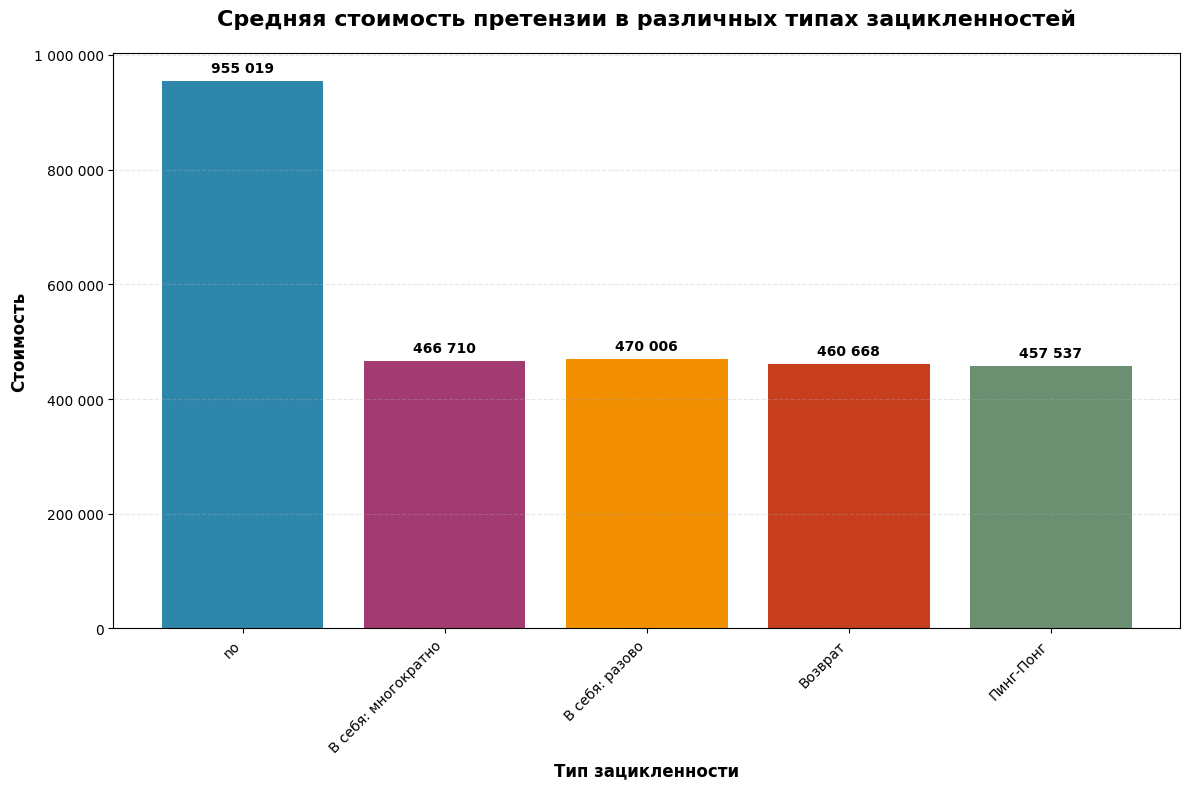

In [29]:
plt.figure(figsize=(12, 8))
bars = plt.bar(price['cycle'], price['Price'], 
               color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B8F71'])

plt.title('Средняя стоимость претензии в различных типах зацикленностей', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Стоимость', fontsize=12, fontweight='bold')
plt.xlabel('Тип зацикленности', fontsize=12, fontweight='bold')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10000,
             f'{height:,.0f}'.replace(',', ' '),
             ha='center', va='bottom', fontweight='bold')

# Форматируем ось Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'.replace(',', ' ')))
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [30]:
data_stat_reg = pd.read_csv('stat_reg_disc.csv').sort_values('duration')
data_stat_reg

,Stage,duration
59591,Урегулирование претензии,2.0
59592,Урегулирование претензии,2.0
59593,Урегулирование претензии,2.0
59594,Урегулирование претензии,2.0
59595,Урегулирование претензии,2.0
...,...,...
1,Урегулирование претензии,1440.0
0,Урегулирование претензии,1440.0
31,Урегулирование претензии,1440.0
60,Урегулирование претензии,1440.0


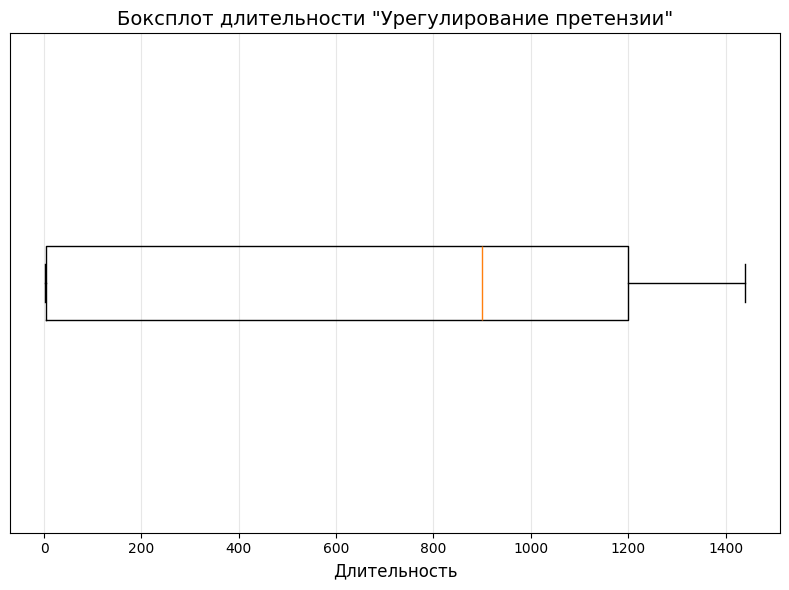

In [31]:
plt.figure(figsize=(8, 6))
plt.boxplot(data_stat_reg['duration'], vert=False)
plt.title('Боксплот длительности "Урегулирование претензии"', fontsize=14)
plt.xlabel('Длительность', fontsize=12)
plt.yticks([])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

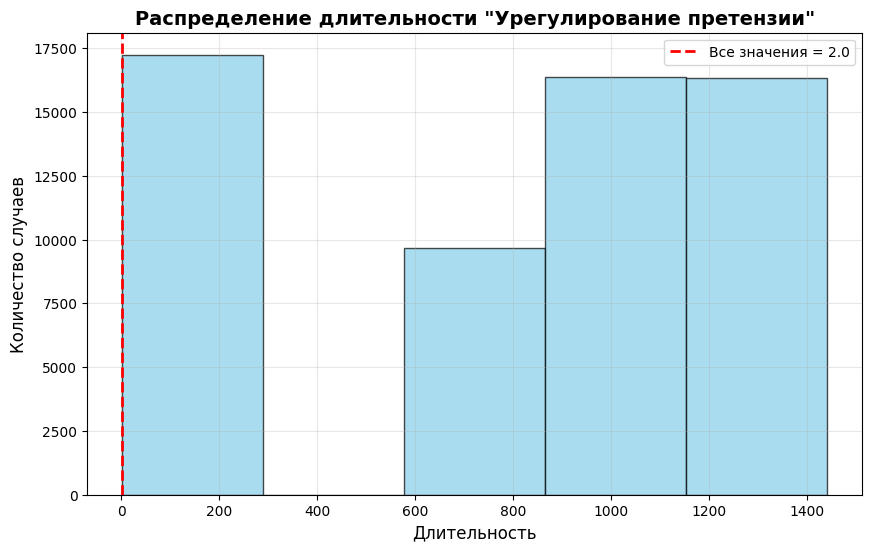

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(data_stat_reg['duration'], bins=5, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(data_stat_reg['duration'].iloc[0], color='red', linestyle='--', linewidth=2, 
            label=f'Все значения = {data_stat_reg["duration"].iloc[0]}')
plt.title('Распределение длительности "Урегулирование претензии"', fontsize=14, fontweight='bold')
plt.xlabel('Длительность', fontsize=12)
plt.ylabel('Количество случаев', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
data_doc_check = pd.read_csv('stat_doc_check.csv').sort_values('duration')
data_doc_check

,Stage,duration
56356,Проверка документов,2.0
56357,Проверка документов,2.0
56358,Проверка документов,2.0
56359,Проверка документов,2.0
56360,Проверка документов,2.0
...,...,...
39,Проверка документов,720.0
40,Проверка документов,720.0
0,Проверка документов,720.0
25,Проверка документов,720.0


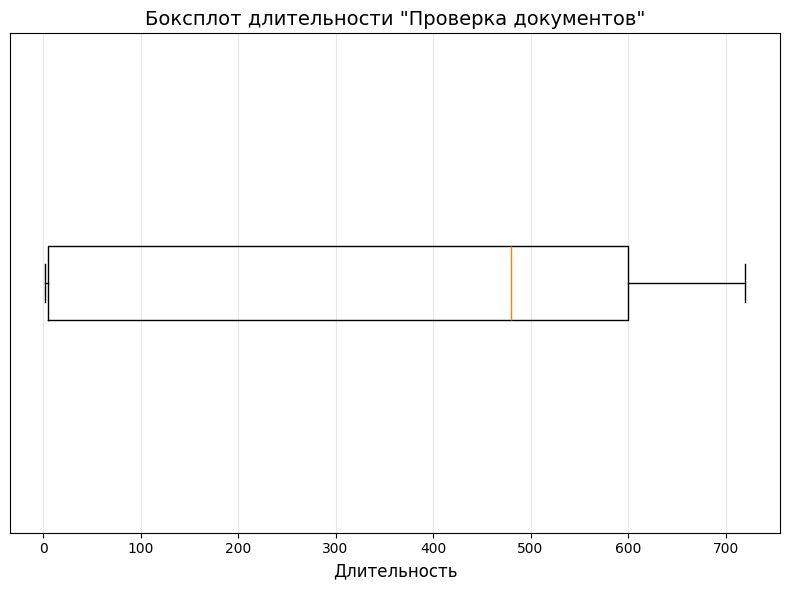

In [34]:
plt.figure(figsize=(8, 6))
plt.boxplot(data_doc_check['duration'], vert=False)
plt.title('Боксплот длительности "Проверка документов"', fontsize=14)
plt.xlabel('Длительность', fontsize=12)
plt.yticks([])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

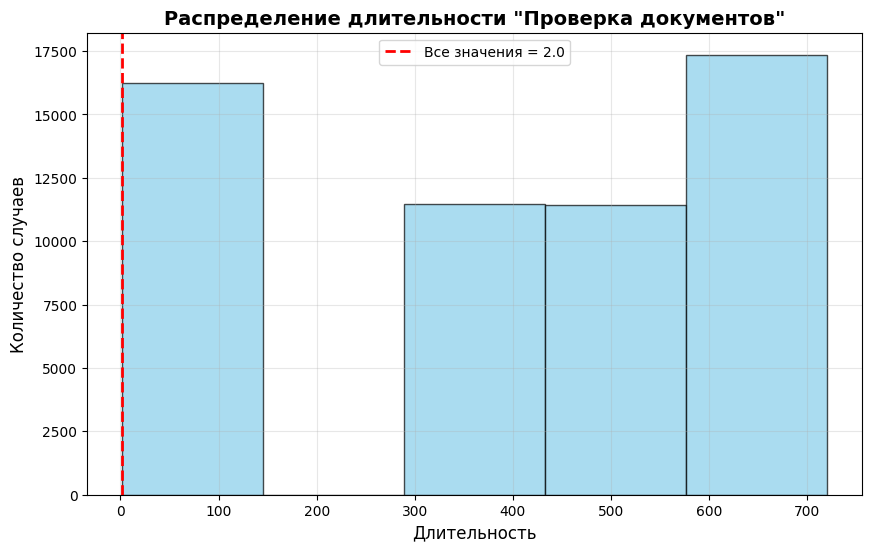

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(data_doc_check['duration'], bins=5, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(data_doc_check['duration'].iloc[0], color='red', linestyle='--', linewidth=2, 
            label=f'Все значения = {data_doc_check["duration"].iloc[0]}')
plt.title('Распределение длительности "Проверка документов"', fontsize=14, fontweight='bold')
plt.xlabel('Длительность', fontsize=12)
plt.ylabel('Количество случаев', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
of_city = data_final[(data_final['Channel'] == 'Офис') & (data_final['Stage'] == 'Регистрация претензии')]
work_of_city = of_city.groupby(['Place', 'Name'])['ID'].count().reset_index()
work_of_city

,Place,Name,ID
0,Барнаул,Алексей Лопухин,67
1,Барнаул,Алёна Волкова,43
2,Барнаул,Анна Егорова,150
3,Барнаул,Владимир Воробьёв,28
4,Барнаул,Геннадий Кривцов,51
...,...,...,...
175,Челябинск,Михаил Трофимов,30
176,Челябинск,Николай Кабанов,12
177,Челябинск,Семён Афанасьев,91
178,Челябинск,Сергей Петров,132
